## Fake News Project - Nicolas Huyghe and Elizabeth Wolfsohn

## All imports

Imports and environment setup

In [ ]:
!pip install gensim
!pip install torch
!pip install transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from tqdm import tqdm
import nltk

from torch.utils.data import TensorDataset, DataLoader

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import tensorflow as tf
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SpatialDropout1D

from transformers import BertTokenizer, BertForSequenceClassification


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

## Data handling, understanding etc

Load and inspect the dataset

In [ ]:
#df=pd.read_csv("./fake_news_dataset.csv", on_bad_lines='skip')
df=pd.read_csv("/content/fake_news_dataset.csv", on_bad_lines='skip')

In [ ]:
# Description of the classes in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20800 non-null  int64 
 1   title   20242 non-null  object
 2   author  18843 non-null  object
 3   text    20761 non-null  object
 4   label   20800 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 812.6+ KB


In [ ]:
# Exemples
df.head(10)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
5,5,Jackie Mason: Hollywood Would Love Trump if He...,Daniel Nussbaum,"In these trying times, Jackie Mason is the Voi...",0
6,6,Life: Life Of Luxury: Elton John’s 6 Favorite ...,NaN,Ever wonder how Britain’s most iconic pop pian...,1
7,7,Benoît Hamon Wins French Socialist Party’s Pre...,Alissa J. Rubin,"PARIS — France chose an idealistic, traditi...",0
8,8,Excerpts From a Draft Script for Donald Trump’...,NaN,Donald J. Trump is scheduled to make a highly ...,0
9,9,"A Back-Channel Plan for Ukraine and Russia, Co...",Megan Twohey and Scott Shane,A week before Michael T. Flynn resigned as nat...,0


In [ ]:

df[df["label"] == 1].head(10)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
6,6,Life: Life Of Luxury: Elton John’s 6 Favorite ...,NaN,Ever wonder how Britain’s most iconic pop pian...,1
12,12,Russian Researchers Discover Secret Nazi Milit...,Amando Flavio,The mystery surrounding The Third Reich and Na...,1
13,13,US Officials See No Link Between Trump and Russia,Jason Ditz,Clinton Campaign Demands FBI Affirm Trump's Ru...,1
14,14,"Re: Yes, There Are Paid Government Trolls On S...",AnotherAnnie,"Yes, There Are Paid Government Trolls On Socia...",1
17,17,Anonymous Donor Pays $2.5 Million To Release E...,Starkman,A Caddo Nation tribal leader has just been fre...,1
18,18,FBI Closes In On Hillary!,The Doc,FBI Closes In On Hillary! Posted on Home » Hea...,1


## Pre-Processing functions (utils)

Define text preprocessing utilities

In [ ]:
# Multiple functions to pre-process the data

# All text from "title" and "text" is put in lowercase
def to_lowercase(df):
    if "combined_text" in df.columns:
        df["combined_text"] = df["combined_text"].fillna("").astype(str).str.lower()
    df["title"] = df["title"].fillna("").astype(str).str.lower()
    df["text"] = df["text"].fillna("").astype(str).str.lower()
    return df

# Remove punctuation from the text
def delete_punctuation(df):
    df["text"] = df["text"].fillna("").astype(str).str.replace(r'[.,!?:";()—–]', '', regex=True)
    if "combined_text" in df.columns:
        df["combined_text"] = df["combined_text"].fillna("").astype(str).str.replace(r'[.,!?":;()—–]', '', regex=True)
    return df

# Stemming
def stem_text(df):
    stemmer = PorterStemmer()
    target_col = "combined_text" if "combined_text" in df.columns else "text"

    df[target_col] = (
        df[target_col].fillna("").astype(str).apply(lambda x: " ".join(stemmer.stem(word) for word in x.split()))
    )

    return df

# Lemmatisation
def lemmatize_text(df):
    lemmatizer=WordNetLemmatizer()
    target_col = "combined_text" if "combined_text" in df.columns else "text"

    df[target_col] = (
        df[target_col].fillna("").astype(str).apply(lambda x: " ".join(lemmatizer.lemmatize(word) for word in x.split()))
    )
    return df

# Combining the "title" and "text" columns into a single column for better processing into a new column "combined_text"
def combine_text_title(df):
    df["combined_text"] = df["title"].fillna("").astype(str) + " " + df["text"].fillna("").astype(str)
    return df

stop_words = set(stopwords.words("english"))

# Remove stopwords
def remove_stopwords(df):
    df["combined_text"] = df["combined_text"].fillna("").astype(str).apply(
        lambda x: " ".join(word for word in x.split() if word not in stop_words)
    )
    return df

## All tests

Checking Pre-Processing functions

In [ ]:
dftest = df.copy()
dftest = combine_text_title(dftest)
dftest.head(10)
dftest = to_lowercase(dftest)
dftest.head(10)
dftest = delete_punctuation(dftest)
dftest.head(10)
dftest = stem_text(dftest)
# dftest.head(10)
#dftest = lemmatize_text(dftest)
dftest.head(10)


,id,title,author,text,label,combined_text
0,0,house dem aide: we didn’t even see comey’s let...,Darrell Lucus,house dem aide we didn’t even see comey’s lett...,1,hous dem aid we didn’t even see comey’ letter ...
1,1,"flynn: hillary clinton, big woman on campus - ...",Daniel J. Flynn,ever get the feeling your life circles the rou...,0,flynn hillari clinton big woman on campu - bre...
2,2,why the truth might get you fired,Consortiumnews.com,why the truth might get you fired october 29 2...,1,whi the truth might get you fire whi the truth...
3,3,15 civilians killed in single us airstrike hav...,Jessica Purkiss,videos 15 civilians killed in single us airstr...,1,15 civilian kill in singl us airstrik have bee...
4,4,iranian woman jailed for fictional unpublished...,Howard Portnoy,print \nan iranian woman has been sentenced to...,1,iranian woman jail for fiction unpublish stori...
5,5,jackie mason: hollywood would love trump if he...,Daniel Nussbaum,in these trying times jackie mason is the voic...,0,jacki mason hollywood would love trump if he b...
6,6,life: life of luxury: elton john’s 6 favorite ...,NaN,ever wonder how britain’s most iconic pop pian...,1,life life of luxuri elton john’ 6 favorit shar...
7,7,benoît hamon wins french socialist party’s pre...,Alissa J. Rubin,paris france chose an idealistic tradition...,0,benoît hamon win french socialist party’ presi...
8,8,excerpts from a draft script for donald trump’...,NaN,donald j trump is scheduled to make a highly a...,0,excerpt from a draft script for donald trump’ ...
9,9,"a back-channel plan for ukraine and russia, co...",Megan Twohey and Scott Shane,a week before michael t flynn resigned as nati...,0,a back-channel plan for ukrain and russia cour...


## Preprocess data

Build preprocessing pipelines

In [ ]:
def preprocess_ml(df, use_stemming=False):
    df = df.dropna(subset=["text"]).copy()
    df = combine_text_title(df)
    df = to_lowercase(df)
    df = delete_punctuation(df)
    df = remove_stopwords(df)

    if use_stemming:
        df = stem_text(df)
    else:
        df = lemmatize_text(df)

    return df

def preprocess_transformer(df):
    df = df.dropna(subset=["text"]).copy()
    df = combine_text_title(df)
    df = to_lowercase(df)
    df = delete_punctuation(df)
    return df

df_processed_ml = preprocess_ml(df)
df_processed_transformer = preprocess_transformer(df)



## Visualization

Explore embeddings and visualization

In [ ]:
#Tokenisation
df = df_processed_ml.copy()
tokenized_texts = [str(text).split() for text in df["combined_text"].fillna('')]


#Test
print(tokenized_texts[0])
first_sample=df["text"].iloc[0]
print(first_sample)

['house', 'dem', 'aide', 'didn’t', 'even', 'see', 'comey’s', 'letter', 'jason', 'chaffetz', 'tweeted', 'house', 'dem', 'aide', 'didn’t', 'even', 'see', 'comey’s', 'letter', 'jason', 'chaffetz', 'tweeted', 'darrell', 'lucus', 'october', '30', '2016', 'subscribe', 'jason', 'chaffetz', 'stump', 'american', 'fork', 'utah', 'image', 'courtesy', 'michael', 'jolley', 'available', 'creative', 'commons-by', 'license', 'apology', 'keith', 'olbermann', 'doubt', 'worst', 'person', 'world', 'weekfbi', 'director', 'james', 'comey', 'according', 'house', 'democratic', 'aide', 'look', 'like', 'also', 'know', 'second-worst', 'person', 'well', 'turn', 'comey', 'sent', 'now-infamous', 'letter', 'announcing', 'fbi', 'looking', 'email', 'may', 'related', 'hillary', 'clinton’s', 'email', 'server', 'ranking', 'democrat', 'relevant', 'committee', 'didn’t', 'hear', 'comey', 'found', 'via', 'tweet', 'one', 'republican', 'committee', 'chairman', 'know', 'comey', 'notified', 'republican', 'chairman', 'democratic'

In [ ]:
w2v_model = Word2Vec(sentences=tokenized_texts,vector_size=100,window=5,min_count=1,workers=4)
print(f"Vocabulaire : {len(w2v_model.wv)} mots")

Vocabulaire : 271735 mots


In [ ]:
neighbors = w2v_model.wv.most_similar("death",topn=5)  #shows the most similar words in the texts to the selected term
for neighbor, score in neighbors:
    print(f"  {neighbor}:   distance cosine = {1-score:.4f}")

  murder:   distance cosine = 0.2845
  tragic:   distance cosine = 0.3603
  disappearance:   distance cosine = 0.3662
  execution:   distance cosine = 0.3668
  victim:   distance cosine = 0.3733


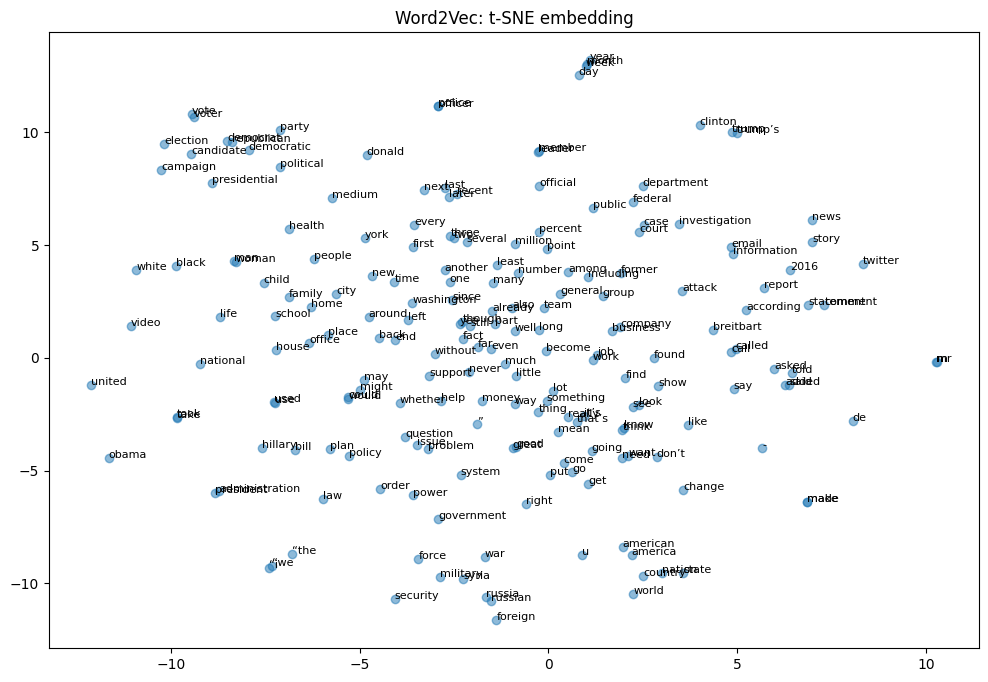

In [ ]:
words = list(w2v_model.wv.index_to_key[:200])  # 200 first words
vectors = np.array([w2v_model.wv[word] for word in words])

tsne = TSNE(n_components=2, random_state=42)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vectors_2d[:,0],vectors_2d[:,1],alpha=0.5)

for i, word in enumerate(words):
    plt.annotate(word,(vectors_2d[i,0], vectors_2d[i,1]),fontsize=8)

plt.title("Word2Vec: t-SNE embedding")
plt.show()

# Models and their results

Model training and evaluation overview of the tested models

## Testing the models


Shared helpers and data preparation

In [ ]:
def article_vector(tokens, model):
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)


In [ ]:
def visualize_confusion_matrix(cm,title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

Function that checks overfitting or underfitting by displaying accuracy & loss curves during train & validation phases

Normal behaviour:

- accuracies are similar for training & validation
- both losses decrease

Overfit behaviour:

- accuracy is greater in training than in validation
- validation loss increases

Underfit behaviour:

- both accuracies are low
- both losses remain high

In [ ]:
def check_train_val_process(history): #check overfitting by displaying accuracy & loss curves during train & validation phases
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Loss'); plt.legend()
    plt.show()

In [ ]:
X = np.array([article_vector(tokens, w2v_model) for tokens in tokenized_texts])
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, df["label"], test_size=0.33, random_state=42, stratify=df["label"])

(20761, 100)


## Logistic Regression

Accuracy : 0.9316


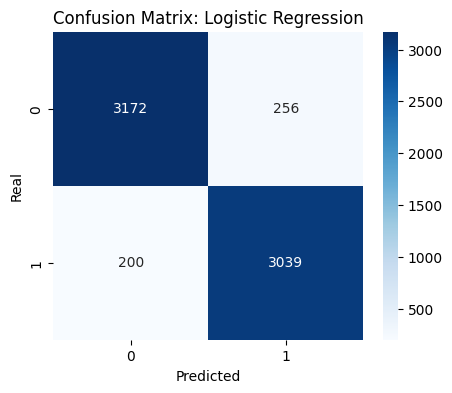

              precision    recall  f1-score   support

        Real       0.94      0.93      0.93      3428
        Fake       0.92      0.94      0.93      3239

    accuracy                           0.93      6667
   macro avg       0.93      0.93      0.93      6667
weighted avg       0.93      0.93      0.93      6667



In [ ]:
#Logistic Regression

lr_model=LogisticRegression(max_iter=1000,solver="lbfgs")
lr_model.fit(X_train, y_train)


y_pred_test=lr_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

cm=confusion_matrix(y_test, y_pred_test)

### Overfitting Check for Logistic Regression

The check_train_val_process function is specifically for models trained with Keras, which provide a history object containing performance metrics across epochs. For sklearn models like Logistic Regression, we assess overfitting by comparing the model's performance (accuracy, precision, recall, F1-score) on the training set versus the test set. A significant drop in performance from training to testing can be due to overfitting.

In [ ]:
y_train_pred = lr_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Logistic Regression Training Accuracy: {train_accuracy:.4f}")

# Print classification report for training set
print(" Training Classification Report ")
print(classification_report(y_train, y_train_pred, target_names=["Real", "Fake"]))

# Print classification report for test set
print(" Test Classification Report")
print(classification_report(y_test, y_pred_test, target_names=["Real", "Fake"]))

Logistic Regression Training Accuracy: 0.9334
 Training Classification Report 
              precision    recall  f1-score   support

        Real       0.94      0.93      0.94      6959
        Fake       0.93      0.93      0.93      6577

    accuracy                           0.93     13536
   macro avg       0.93      0.93      0.93     13536
weighted avg       0.93      0.93      0.93     13536

 Test Classification Report
              precision    recall  f1-score   support

        Real       0.94      0.93      0.93      3428
        Fake       0.92      0.94      0.93      3239

    accuracy                           0.93      6667
   macro avg       0.93      0.93      0.93      6667
weighted avg       0.93      0.93      0.93      6667



## SVM

Accuracy : 0.9430


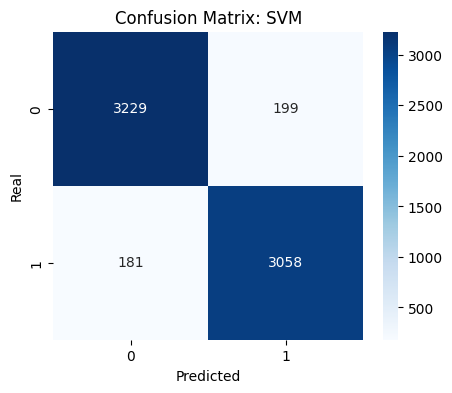

              precision    recall  f1-score   support

        Real       0.95      0.94      0.94      3428
        Fake       0.94      0.94      0.94      3239

    accuracy                           0.94      6667
   macro avg       0.94      0.94      0.94      6667
weighted avg       0.94      0.94      0.94      6667



In [ ]:
#SVM
svm_model=svm.SVC()
svm_model.fit(X_train, y_train)


y_pred=svm_model.predict(X_test)
cm=confusion_matrix(y_test, y_pred)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

visualize_confusion_matrix(cm, "Confusion Matrix: SVM")

### Overfitting Check for SVM

Similar to Logistic Regression, we assess overfitting for SVM by comparing its performance metrics on the training set versus the test set.

In [ ]:

y_train_pred_svm = svm_model.predict(X_train)
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
print(f"SVM Training Accuracy: {train_accuracy_svm:.4f}")


print("Training Classification Report (SVM) ")
print(classification_report(y_train, y_train_pred_svm, target_names=["Real", "Fake"]))

print("Test Classification Report (SVM) ")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

SVM Training Accuracy: 0.9501

 Training Classification Report (SVM) 
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      6959
        Fake       0.95      0.95      0.95      6577

    accuracy                           0.95     13536
   macro avg       0.95      0.95      0.95     13536
weighted avg       0.95      0.95      0.95     13536


 Test Classification Report (SVM) 
              precision    recall  f1-score   support

        Real       0.95      0.94      0.94      3428
        Fake       0.94      0.94      0.94      3239

    accuracy                           0.94      6667
   macro avg       0.94      0.94      0.94      6667
weighted avg       0.94      0.94      0.94      6667



## Random Forest

Accuracy: 0.8973


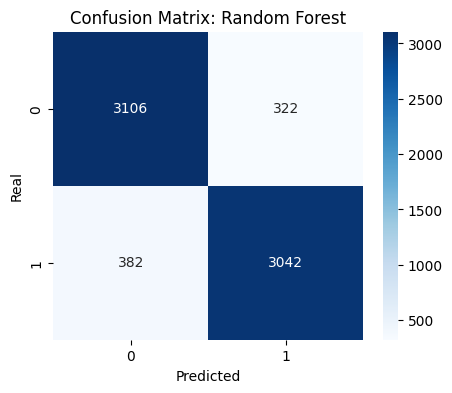

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=4, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
cm = confusion_matrix(y_test, y_pred)
visualize_confusion_matrix(cm, "Confusion Matrix: Random Forest")


### Overfitting Check for Random Forest

Similar to Logistic Regression and SVM, we assess overfitting for Random Forest by comparing its performance metrics on the training set versus the test set.

In [ ]:
# Calculate and print training accuracy for Random Forest
y_train_pred_rf = rf_model.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
print(f"Random Forest Training Accuracy: {train_accuracy_rf:.4f}")

# Print classification report for training set
print("Training Classification Report (Random Forest) ")
print(classification_report(y_train, y_train_pred_rf, target_names=["Real", "Fake"]))

# Print classification report for test set (already computed in previous cell)
print("Test Classification Report (Random Forest) ")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

Random Forest Training Accuracy: 0.9385
Training Classification Report (Random Forest) 
              precision    recall  f1-score   support

        Real       0.93      0.95      0.94      6959
        Fake       0.95      0.93      0.94      6950

    accuracy                           0.94     13909
   macro avg       0.94      0.94      0.94     13909
weighted avg       0.94      0.94      0.94     13909

Test Classification Report (Random Forest) 
              precision    recall  f1-score   support

        Real       0.89      0.91      0.90      3428
        Fake       0.90      0.89      0.90      3424

    accuracy                           0.90      6852
   macro avg       0.90      0.90      0.90      6852
weighted avg       0.90      0.90      0.90      6852



## Bi-LSTM

In [ ]:
#pip show keras tensorflow

Name: keras
Version: 3.14.0
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: /home/user/Documents/fake_news_project/deep_learning_venv/lib/python3.12/site-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow
---
Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/user/Documents/fake_news_project/deep_learning_venv/lib/python3.12/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


### With mechanisms limiting overfitting

W0000 00:00:1777557409.657854   21497 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 67s 138ms/step - accuracy: 0.5174 - loss: 0.7290 - val_accuracy: 0.5143 - val_loss: 0.6482
Epoch 2/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 57s 136ms/step - accuracy: 0.7039 - loss: 0.5166 - val_accuracy: 0.9316 - val_loss: 0.2995
Epoch 3/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 58s 136ms/step - accuracy: 0.8970 - loss: 0.3240 - val_accuracy: 0.9418 - val_loss: 0.2274
Epoch 4/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 57s 135ms/step - accuracy: 0.9300 - loss: 0.2554 - val_accuracy: 0.9532 - val_loss: 0.1949
Epoch 5/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 57s 136ms/step - accuracy: 0.9467 - loss: 0.2227 - val_accuracy: 0.9568 - val_loss: 0.1752
Epoch 6/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 59s 138ms/step - accuracy: 0.9513 - loss: 0.1994 - val_accuracy: 0.9529 - val_loss: 0.1881
Epoch 7/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 58s 138ms/step - accuracy: 0.9564 - loss: 0.1878 - val_accuracy: 0.9556 - val_loss: 0.1795
Epoch 8/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 58s 138ms/step - accuracy: 0.9597 - loss: 0

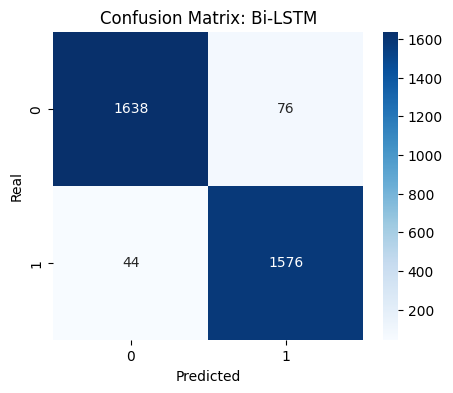

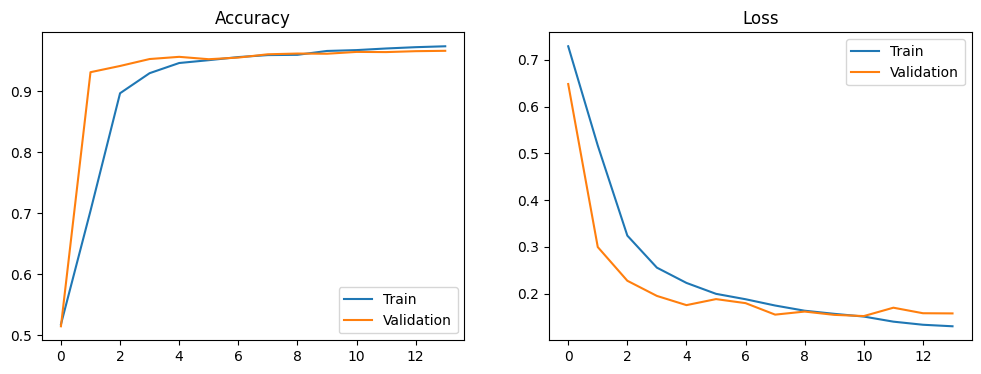

In [ ]:


df = df_processed_transformer.copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    df["combined_text"], df["label"],
    test_size=0.33, random_state=42, stratify=df["label"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val.values,   y_val.values))
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test.values,  y_test.values))

batch_size = 32
train_dataset = train_dataset.shuffle(10000).batch(batch_size)
val_dataset   = val_dataset.batch(batch_size)
test_dataset  = test_dataset.batch(batch_size)


MAX_TOKENS = 20000
SEQ_LEN    = 200
EMBED_DIM  = 100

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQ_LEN
)
vectorize_layer.adapt(train_dataset.map(lambda x, y: x))

#Embedding matrice, from word2vec
vocab = vectorize_layer.get_vocabulary()
vocab_size = len(vocab)

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
for i, word in enumerate(vocab):
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# Modelling
model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(
        vocab_size, EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=False
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        32, return_sequences=True, use_cudnn=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        recurrent_regularizer=tf.keras.regularizers.l2(1e-4)
    )),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        16, use_cudnn=False,
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        recurrent_regularizer=tf.keras.regularizers.l2(1e-4)
    )),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(32, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

y_pred_logits = model.predict(test_dataset)
y_pred = (tf.sigmoid(y_pred_logits).numpy().flatten() > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["REAL", "FAKE"]))
cm = confusion_matrix(y_test, y_pred)
visualize_confusion_matrix(cm, "Confusion Matrix: Bi-LSTM")
check_train_val_process(history)

### Without mechanisms limiting overfitting

In [ ]:
df = df_processed_transformer.copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    df["combined_text"], df["label"],
    test_size=0.33, random_state=42, stratify=df["label"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val.values,   y_val.values))
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test.values,  y_test.values))

batch_size = 32
train_dataset = train_dataset.shuffle(10000).batch(batch_size)
val_dataset   = val_dataset.batch(batch_size)
test_dataset  = test_dataset.batch(batch_size)


MAX_TOKENS = 20000
SEQ_LEN    = 200
EMBED_DIM  = 100

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQ_LEN
)
vectorize_layer.adapt(train_dataset.map(lambda x, y: x))

#Embedding matrice, from word2vec
vocab = vectorize_layer.get_vocabulary()
vocab_size = len(vocab)

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
for i, word in enumerate(vocab):
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# Modelling
model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(
        vocab_size, EMBED_DIM,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=False
     ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        32, return_sequences=True, use_cudnn=False,
        # kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        # recurrent_regularizer=tf.keras.regularizers.l2(1e-4)
    )),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        16, use_cudnn=False,
        #kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        #recurrent_regularizer=tf.keras.regularizers.l2(1e-4)
    )),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(32, activation='relu',
        #kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
    #tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)
model.summary()

# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True
# )

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    #callbacks=[early_stop]
)

y_pred_logits = model.predict(test_dataset)
y_pred = (tf.sigmoid(y_pred_logits).numpy().flatten() > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["REAL", "FAKE"]))
cm = confusion_matrix(y_test, y_pred)
visualize_confusion_matrix(cm, "Confusion Matrix: Bi-LSTM")
check_train_val_process(history)

## CNN

Epoch 1/10


/home/user/Documents/fake_news_project/deep_learning_venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


379/379 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8879 - loss: 0.2376 - val_accuracy: 0.9837 - val_loss: 0.0425
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9861 - loss: 0.0388 - val_accuracy: 0.9903 - val_loss: 0.0301
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accuracy: 0.9876 - val_loss: 0.0330
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9906 - val_loss: 0.0291
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9913 - val_loss: 0.0299
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9866 - val_loss: 0.0495
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 1.0000 - loss: 4.8248e-04 - val_accuracy: 0.9913 - val_loss: 0.0352
Epoch 8/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 1.0000 - loss: 2.4250e-04 - val

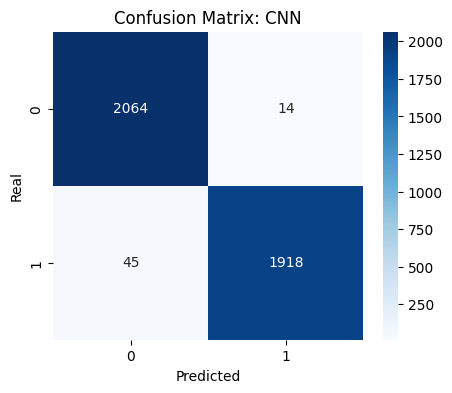

              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      2078
        Fake       0.99      0.98      0.98      1963

    accuracy                           0.99      4041
   macro avg       0.99      0.99      0.99      4041
weighted avg       0.99      0.99      0.99      4041



In [ ]:
# Prepare data
df = df_processed_transformer.copy()
vocab_size = 10000
max_length = 500

# Split data
X_train_val_text, X_test_text, y_train_val, y_test = train_test_split(
    df["combined_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
 )
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_val_text, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
 )

# Tokenization
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Create model
model_cnn = Sequential([
    Embedding(vocab_size, 100, input_length=max_length),
    SpatialDropout1D(0.2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val_pad, y_val),
    verbose=1
)

# Evaluation
test_loss, test_accuracy = model_cnn.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
y_pred_cnn = (model_cnn.predict(X_test_pad) > 0.5).astype("int32")
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
visualize_confusion_matrix(cm_cnn, "Confusion Matrix: CNN")
print(classification_report(y_test, y_pred_cnn, target_names=["Real", "Fake"]))

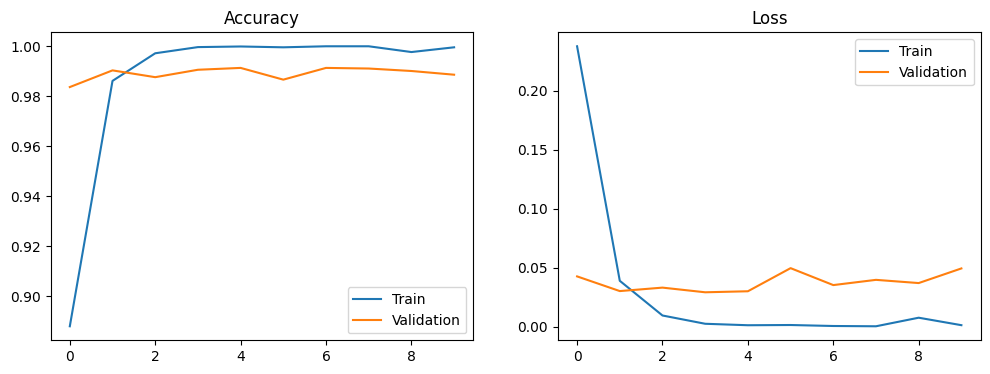

In [ ]:
check_train_val_process(history_cnn)

## Bert

**Phase: Transformer model placeholder (BERT)**

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 1/3  |  Train loss: 0.0399  |  Val loss: 0.0149  |  Val acc: 0.9968


Epoch 2/3  |  Train loss: 0.0122  |  Val loss: 0.0114  |  Val acc: 0.9975


Epoch 3/3  |  Train loss: 0.0046  |  Val loss: 0.0111  |  Val acc: 0.9985


Évaluation finale: 100%|██████████| 253/253 [00:36<00:00,  7.01it/s]



BERT Accuracy : 0.9985


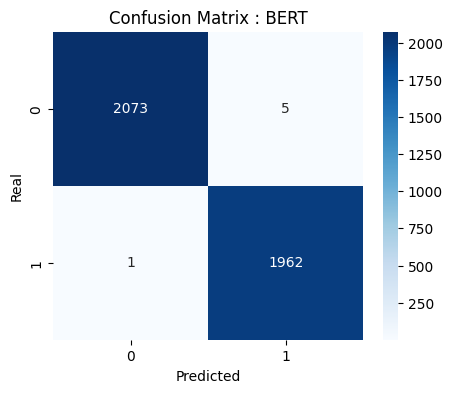

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2078
        Fake       1.00      1.00      1.00      1963

    accuracy                           1.00      4041
   macro avg       1.00      1.00      1.00      4041
weighted avg       1.00      1.00      1.00      4041



In [ ]:
# df_bert = df_processed_transformer.copy()

# X_train_text, X_test_text, y_train, y_test = train_test_split(
#     df_bert["combined_text"], df_bert["label"],
#     test_size=0.2, random_state=42, stratify=df_bert["label"])

# # Tokenizing
# tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# train_enc = tokenizer(list(X_train_text), padding=True, truncation=True,
#         max_length=128, return_tensors="pt")
# test_enc  = tokenizer(list(X_test_text), padding=True, truncation=True,
#         max_length=128, return_tensors="pt")

# # Creating DataLoaders
# train_loader = DataLoader(
#     TensorDataset(train_enc["input_ids"], train_enc["attention_mask"],
#                   torch.tensor(y_train.values)),
#     batch_size=16, shuffle=True)
# test_loader = DataLoader(
#     TensorDataset(test_enc["input_ids"], test_enc["attention_mask"],
#                   torch.tensor(y_test.values)),
#     batch_size=16)

# # Creating model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_bert = BertForSequenceClassification.from_pretrained(
#     "bert-base-uncased", num_labels=2).to(device)

# optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

# # Training loop with early stopping
# N_EPOCHS       = 3
# PATIENCE       = 2
# best_val_loss  = float("inf")
# epochs_no_improve = 0

# for epoch in range(1, N_EPOCHS + 1):

#     # Training phase
#     model_bert.train()
#     train_loss = 0.0

#     progress = tqdm(train_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Train]", leave=False)
#     for ids, mask, labels in progress:
#         ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

#         optimizer.zero_grad()
#         loss = model_bert(ids, attention_mask=mask, labels=labels).loss
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()
#         progress.set_postfix(loss=f"{loss.item():.4f}")

#     avg_train_loss = train_loss / len(train_loader)

#     # Validation phase
#     model_bert.eval()
#     val_loss = 0.0
#     val_preds, val_true = [], []

#     with torch.no_grad():
#         for ids, mask, labels in tqdm(test_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Val]  ", leave=False):
#             ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
#             outputs = model_bert(ids, attention_mask=mask, labels=labels)
#             val_loss += outputs.loss.item()
#             val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
#             val_true.extend(labels.cpu().numpy())

#     avg_val_loss = val_loss / len(test_loader)
#     val_acc = accuracy_score(val_true, val_preds)

#     print(f"Epoch {epoch}/{N_EPOCHS}  |  "
#           f"Train loss: {avg_train_loss:.4f}  |  "
#           f"Val loss: {avg_val_loss:.4f}  |  "
#           f"Val acc: {val_acc:.4f}")

#     # Saving best model / early stopping check
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         epochs_no_improve = 0
#         torch.save(model_bert.state_dict(), "best_bert.pt")
#     else:
#         epochs_no_improve += 1
#         if epochs_no_improve >= PATIENCE:
#             print(f"Early stopping déclenché à l'époque {epoch} (patience={PATIENCE})")
#             break

# # Final evaluation
# model_bert.load_state_dict(torch.load("best_bert.pt"))
# model_bert.eval()
# preds = []

# with torch.no_grad():
#     for ids, mask, _ in tqdm(test_loader, desc="Évaluation finale"):
#         ids, mask = ids.to(device), mask.to(device)
#         preds.extend(torch.argmax(model_bert(ids, attention_mask=mask).logits, dim=1).cpu().numpy())

# print(f"BERT Accuracy : {accuracy_score(y_test, preds):.4f}")
# cm_bert = confusion_matrix(y_test, preds)
# visualize_confusion_matrix(cm_bert, "Confusion Matrix : BERT")
# print(classification_report(y_test, preds, target_names=["Real", "Fake"]))

In [ ]:
df_bert = df_processed_transformer.copy()


X_train_text, X_temp, y_train, y_temp = train_test_split(
    df_bert["combined_text"], df_bert["label"],
    test_size=0.33, random_state=42, stratify=df_bert["label"]
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)


# Tokenizing
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(list(X_train_text), padding=True, truncation=True,
        max_length=128, return_tensors="pt")
val_enc   = tokenizer(list(X_val_text), padding=True, truncation=True,
        max_length=128, return_tensors="pt")
test_enc  = tokenizer(list(X_test_text), padding=True, truncation=True,
        max_length=128, return_tensors="pt")

# Creating DataLoaders
train_loader = DataLoader(
    TensorDataset(train_enc["input_ids"], train_enc["attention_mask"],
                  torch.tensor(y_train.values)),
    batch_size=16, shuffle=True)

val_loader = DataLoader(
    TensorDataset(val_enc["input_ids"], val_enc["attention_mask"],
                  torch.tensor(y_val.values)),
    batch_size=16)



test_loader = DataLoader(
    TensorDataset(test_enc["input_ids"], test_enc["attention_mask"],
                  torch.tensor(y_test.values)),
    batch_size=16)

# Creating model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2).to(device)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

# Training loop with early stopping
N_EPOCHS       = 3
PATIENCE       = 2
best_val_loss  = float("inf")
epochs_no_improve = 0


for epoch in range(1, N_EPOCHS + 1):

    # Training phase
    model_bert.train()
    train_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Train]", leave=False)
    for ids, mask, labels in progress:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

        optimizer.zero_grad()
        loss = model_bert(ids, attention_mask=mask, labels=labels).loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)

    model_bert.eval()
    val_loss = 0.0
    val_preds, val_true = [], []

    with torch.no_grad():
        for ids, mask, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{N_EPOCHS} [Val]  ", leave=False):
            ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
            outputs = model_bert(ids, attention_mask=mask, labels=labels)
            val_loss += outputs.loss.item()
            val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)




    print(f"Epoch {epoch}/{N_EPOCHS}  |  "
          f"Train loss: {avg_train_loss:.4f}  |  "
          f"Val loss: {avg_val_loss:.4f}  |  "
          f"Val acc: {val_acc:.4f}")

    # Saving best model / early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model_bert.state_dict(), "best_bert.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping déclenché à l'époque {epoch} (patience={PATIENCE})")
            break


model_bert.load_state_dict(torch.load("best_bert.pt"))
model_bert.eval()
preds = []

with torch.no_grad():
    for ids, mask, _ in tqdm(test_loader, desc="Évaluation finale"):
        ids, mask = ids.to(device), mask.to(device)
        preds.extend(torch.argmax(model_bert(ids, attention_mask=mask).logits, dim=1).cpu().numpy())

print(f"BERT Accuracy : {accuracy_score(y_test, preds):.4f}")
cm_bert = confusion_matrix(y_test, preds)
visualize_confusion_matrix(cm_bert, "Confusion Matrix : BERT")
print(classification_report(y_test, preds, target_names=["Real", "Fake"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3 [Train]:   0%|          | 1

# References

https://www.geeksforgeeks.org/nlp/using-countvectorizer-to-extracting-features-from-text/ : Using CountVectorizer to Extracting Features from Text by Khushali Verma

https://radimrehurek.com/gensim/models/word2vec.html : Word2Vec Embedding

https://www.mdpi.com/2624-800X/5/3/43 : Jayanti Rout,Minati Mishra and Manob Jyoti Saikia Towards Reliable Fake News Detection: Enhanced Attention-Based Transformer Model

https://www.mdpi.com/2073-431X/14/9/394 : Fake News Detection Using Machine Learning and Deep Learning Algorithms: A Comprehensive Review and Future Perspectives by Faisal A. Alshuwaier and Fawaz A. Alsulaiman
--> Compares multiple models

https://www.geeksforgeeks.org/nlp/bidirectional-lstm-in-nlp/ : Bi LSTM implementation

https://www.geeksforgeeks.org/nlp/text-classification-using-cnn/ : CNN implementation

